# Puzzle Velocity Analysis

Calibration analysis of `docs/puzzle-velocity.csv` — the per-ticket time log for the
lccjs project's Yegor-style microtask workflow (dual H/C estimates + actuals).

**Data source:** `stats/puzzle-velocity-enriched.csv`, produced by `stats/enrich.py`,
which augments the raw CSV with three enrichment layers:

1. **Git churn** (`insertions`/`deletions`/`files_changed`/`total_loc`) from each row's
   `closed_commit`. Six rows close *cross-repo* (the Claude-skill tickets land in
   `avidrucker/claude-config`), so their SHAs don't resolve here → `cross_repo=True`,
   churn `NaN`. That flag is itself a useful signal.
2. **GitHub issue timestamps** (`issue_created`/`issue_closed`) → **lead time**
   (backlog wait: issue filed → work started) vs the hands-on **cycle time** in `actual_min`.
3. **Notes-parsed flags** (`f_worktree`, `f_overrun`, `f_test_loop`, `f_retro_c`) +
   derived `c_ratio = c_min / actual_min` (the over-pad factor) and `h_ratio`.

> **To refresh the data:** `python3 stats/enrich.py` (needs `git` + `gh` for the
> churn/issue layers; degrades gracefully offline).

---

## Key terms

| Field | Meaning |
|---|---|
| `h_min` | "Hard cap" estimate — the 60-min Yegor ceiling, not a forecast |
| `c_min` | "Calibrated" estimate — the actual best-guess forecast |
| `actual_min` | Summed hands-on minutes (excludes idle/compaction gaps) |
| `c_ratio` | `c_min / actual_min`. **>1 = over-padded** (finished faster than forecast); `1.0` = perfect; **<1 = overrun** |
| `lead_min` | Issue created → work started (backlog age) |
| `span_min` | started → finished wall-clock (includes idle gaps) |


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams.update({"figure.figsize": (11, 5), "axes.grid": True, "grid.alpha": 0.3})

# Resolve the enriched CSV whether the notebook runs from stats/ or repo root.
candidates = [Path("puzzle-velocity-enriched.csv"),
              Path("stats/puzzle-velocity-enriched.csv")]
csv_path = next((p for p in candidates if p.exists()), None)
assert csv_path, "Run `python3 stats/enrich.py` first to generate the enriched CSV."

df = pd.read_csv(csv_path)
# Chronological order by when work was committed / finished.
df["commit_date"] = pd.to_datetime(df["commit_date"], errors="coerce", utc=True)
df["issue_created"] = pd.to_datetime(df["issue_created"], errors="coerce", utc=True)
df["issue_closed"] = pd.to_datetime(df["issue_closed"], errors="coerce", utc=True)
df = df.sort_values("issue_closed", kind="stable").reset_index(drop=True)
df["seq"] = range(1, len(df) + 1)  # chronological closing order

print(f"{len(df)} puzzles | roles: {df['role'].value_counts().to_dict()}")
df[["ticket", "role", "h_min", "c_min", "actual_min", "c_ratio", "total_loc", "cross_repo"]].head(10)


41 puzzles | roles: {'WRITER': 19, 'DEV': 16, 'ARC': 5, 'TEST': 1}


,ticket,role,h_min,c_min,actual_min,c_ratio,total_loc,cross_repo
0,119,WRITER,60,NaN,10.00,NaN,67.0,False
1,120,WRITER,60,NaN,16.00,NaN,49.0,False
2,121,WRITER,60,NaN,2.00,NaN,63.0,False
3,122,WRITER,60,NaN,3.00,NaN,103.0,False
4,123,WRITER,60,NaN,2.00,NaN,69.0,False
5,124,ARC,30,4.0,1.50,2.667,120.0,False
6,126,WRITER,30,3.0,1.00,3.000,3.0,False
7,109,WRITER,60,12.0,4.00,3.000,195.0,False
8,110,WRITER,60,3.0,1.25,2.400,82.0,False
9,113,WRITER,60,10.0,2.78,3.597,188.0,False


## 1. Headline numbers

How big is the over-padding problem, and how much real work is logged?

In [2]:
has_c = df[df["c_min"].notna()].copy()
overruns = has_c[has_c["c_ratio"] < 1.0]

print(f"Total puzzles logged ........... {len(df)}")
print(f"  with a C estimate ............ {len(has_c)}")
print(f"  cross-repo closes ............ {int((df['cross_repo'] == True).sum())}")
print(f"Total hands-on minutes ......... {df['actual_min'].sum():.1f} min  (~{df['actual_min'].sum()/60:.1f} h)")
print(f"Total code churn (in-repo) ..... +{int(df['insertions'].sum())} / -{int(df['deletions'].sum())} LOC across {int(df['files_changed'].sum())} file-changes")
print()
print(f"Median C-ratio (over-pad factor) {has_c['c_ratio'].median():.2f}x")
print(f"Mean   C-ratio ................. {has_c['c_ratio'].mean():.2f}x")
print(f"Overruns (C-ratio < 1.0) ....... {len(overruns)} / {len(has_c)}  -> {overruns['ticket'].tolist()}")


Total puzzles logged ........... 41
  with a C estimate ............ 36
  cross-repo closes ............ 6
Total hands-on minutes ......... 200.8 min  (~3.3 h)
Total code churn (in-repo) ..... +3925 / -231 LOC across 61 file-changes

Median C-ratio (over-pad factor) 2.51x
Mean   C-ratio ................. 3.05x
Overruns (C-ratio < 1.0) ....... 2 / 36  -> [135, 141]


## 2. Estimation calibration — the central story

Every row's notes obsess over the same pattern: **C estimates run consistently
~2–3x too high**. Let's see it directly. A point above the dashed `1.0` line means
the task finished *faster* than the calibrated forecast (over-padded); below it
means an overrun.

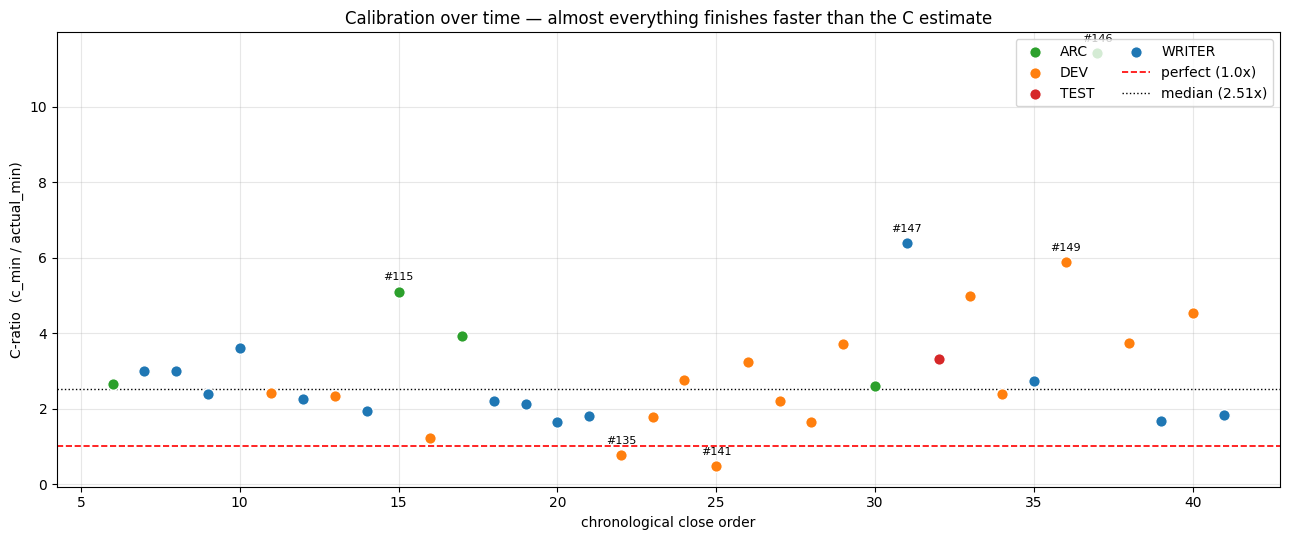

In [3]:
fig, ax = plt.subplots(figsize=(13, 5.5))
role_colors = {"WRITER": "#1f77b4", "DEV": "#ff7f0e", "ARC": "#2ca02c", "TEST": "#d62728"}
for role, g in has_c.groupby("role"):
    ax.scatter(g["seq"], g["c_ratio"], label=role, s=70,
               color=role_colors.get(role, "#888"), zorder=3, edgecolor="white")
ax.axhline(1.0, ls="--", color="red", lw=1.2, label="perfect (1.0x)")
ax.axhline(has_c["c_ratio"].median(), ls=":", color="black", lw=1,
           label=f"median ({has_c['c_ratio'].median():.2f}x)")
# Annotate the extremes.
for _, r in has_c.iterrows():
    if r["c_ratio"] > 5 or r["c_ratio"] < 1:
        ax.annotate(f"#{int(r['ticket'])}", (r["seq"], r["c_ratio"]),
                    textcoords="offset points", xytext=(0, 8), ha="center", fontsize=8)
ax.set(xlabel="chronological close order", ylabel="C-ratio  (c_min / actual_min)",
       title="Calibration over time — almost everything finishes faster than the C estimate")
ax.legend(loc="upper right", ncol=2)
plt.tight_layout(); plt.show()


**Read:** the cloud sits well above `1.0` — the calibrated estimate is systematically
padded. The two notable overruns (#135, #141) are both DEV edit/test-loop tasks, which
the notes hypothesize is where actuals get pulled *up*. The sky-high points (#146 11.4x,
#147 6.4x, #148/#149 ~5–6x) are research spikes / tiny doc edits / spec-transcription —
work where "padding for unknowns" met "there were no unknowns".

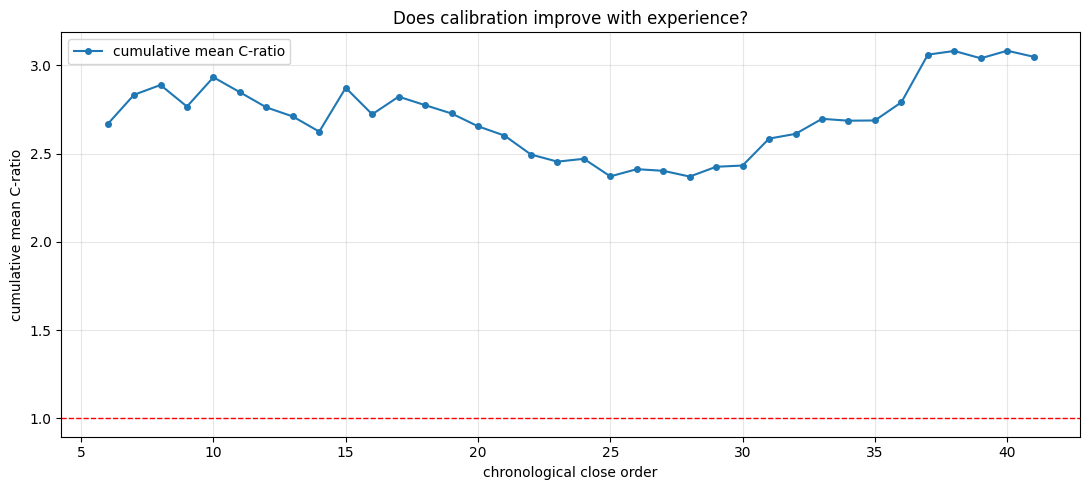

In [4]:
# Calibration trend: is the over-padding shrinking as more data accrues?
fig, ax = plt.subplots()
ax.plot(has_c["seq"], has_c["c_ratio"].expanding().mean(), marker="o", ms=4,
        label="cumulative mean C-ratio")
ax.axhline(1.0, ls="--", color="red", lw=1)
ax.set(xlabel="chronological close order", ylabel="cumulative mean C-ratio",
       title="Does calibration improve with experience?")
ax.legend(); plt.tight_layout(); plt.show()


## 3. Calibration by role

The notes claim "weightier tasks attract heavier padding (ARC > DEV/parity)". Let's test it.

,n,median_c_ratio,mean_c_ratio,mean_actual,mean_c
role,,,,,
ARC,5,3.92,5.14,2.93,15.40
TEST,1,3.31,3.31,9.07,30.00
DEV,16,2.41,2.76,5.79,10.88
WRITER,14,2.22,2.61,3.68,8.68


/tmp/claude-1000/ipykernel_700923/105065333.py:13: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=order, showmeans=True, patch_artist=True)


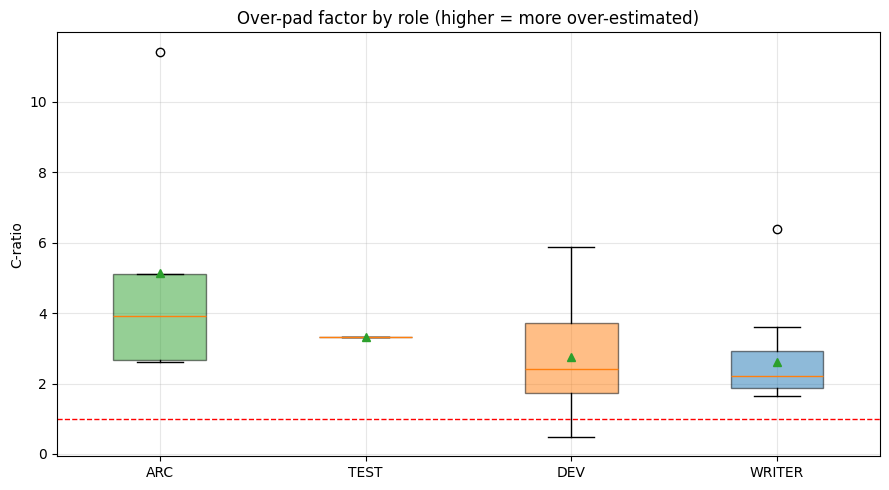

In [5]:
by_role = has_c.groupby("role").agg(
    n=("ticket", "size"),
    median_c_ratio=("c_ratio", "median"),
    mean_c_ratio=("c_ratio", "mean"),
    mean_actual=("actual_min", "mean"),
    mean_c=("c_min", "mean"),
).sort_values("median_c_ratio", ascending=False)
display(by_role.round(2))

fig, ax = plt.subplots(figsize=(9, 5))
order = by_role.index.tolist()
data = [has_c[has_c["role"] == r]["c_ratio"].values for r in order]
bp = ax.boxplot(data, labels=order, showmeans=True, patch_artist=True)
for patch, r in zip(bp["boxes"], order):
    patch.set_facecolor(role_colors.get(r, "#888")); patch.set_alpha(0.5)
ax.axhline(1.0, ls="--", color="red", lw=1)
ax.set(ylabel="C-ratio", title="Over-pad factor by role (higher = more over-estimated)")
plt.tight_layout(); plt.show()


## 4. Git-churn enrichment — does code volume explain effort?

The user's hypothesis: *lines changed could signal drift*. Here we test whether
`actual_min` and the over-pad factor track with `total_loc`. Cross-repo rows are
excluded (no churn data).

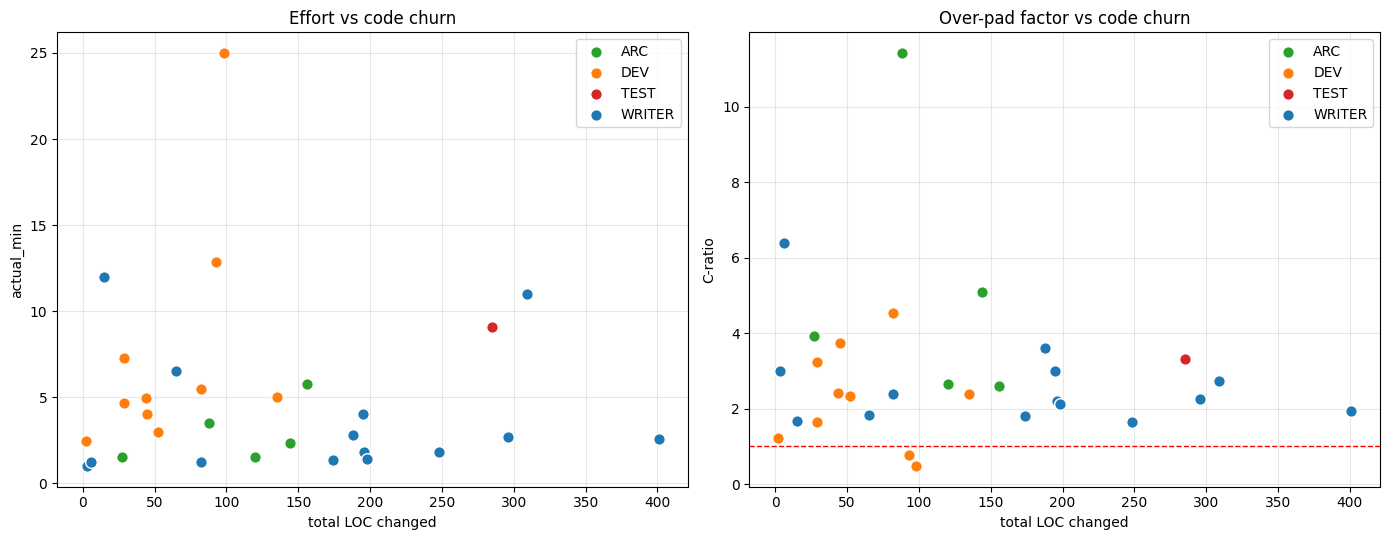

Correlations (in-repo rows only):
total_loc       -0.027
actual_min       1.000
c_ratio         -0.308
files_changed    0.632

LOC↔actual_min Pearson r = -0.027


In [6]:
in_repo = has_c[has_c["cross_repo"] != True].dropna(subset=["total_loc"]).copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for role, g in in_repo.groupby("role"):
    axes[0].scatter(g["total_loc"], g["actual_min"], label=role, s=70,
                    color=role_colors.get(role, "#888"), edgecolor="white", zorder=3)
    axes[1].scatter(g["total_loc"], g["c_ratio"], label=role, s=70,
                    color=role_colors.get(role, "#888"), edgecolor="white", zorder=3)
axes[0].set(xlabel="total LOC changed", ylabel="actual_min", title="Effort vs code churn")
axes[1].set(xlabel="total LOC changed", ylabel="C-ratio", title="Over-pad factor vs code churn")
axes[1].axhline(1.0, ls="--", color="red", lw=1)
for a in axes:
    a.legend()
plt.tight_layout(); plt.show()

print("Correlations (in-repo rows only):")
print(in_repo[["total_loc", "actual_min", "c_ratio", "files_changed"]].corr(numeric_only=True)["actual_min"].round(3).to_string())
print(f"\nLOC↔actual_min Pearson r = {in_repo['total_loc'].corr(in_repo['actual_min']):.3f}")


**Read:** if `total_loc` ↔ `actual_min` correlation is weak, it confirms a known
quirk of this workflow — much of the logged time is *thinking/reading/verifying*, not
typing. A 400-LOC mechanical glossary write (#128) can be faster than a 90-LOC
investigation that hit a redesign (#141). So **LOC is a poor effort proxy here**, but a
good *drift detector*: a row with high LOC and a tiny `actual_min` is bulk-generated;
high `actual_min` with low LOC is investigation-heavy.

## 5. Cross-repo work

Six tickets closed in `avidrucker/claude-config` (the lccjs-assembly Claude skill).
They have no local churn but full time/estimate data.

In [7]:
xr = df[df["cross_repo"] == True][["ticket", "role", "c_min", "actual_min", "c_ratio", "f_crossrepo_note"]]
display(xr)
print(f"Cross-repo mean C-ratio: {xr['c_ratio'].mean():.2f}x  (vs in-repo {in_repo['c_ratio'].mean():.2f}x)")
print("These are all DEV skill-authoring tickets; note the high over-pad — spec/source")
print("transcription is fast once context is warm, but was budgeted for research.")


,ticket,role,c_min,actual_min,c_ratio,f_crossrepo_note
22,137,DEV,8.0,4.52,1.770,True
23,138,DEV,8.0,2.90,2.759,True
26,139,DEV,12.0,5.43,2.210,True
28,140,DEV,10.0,2.70,3.704,True
32,148,DEV,7.0,1.40,5.000,True
35,149,DEV,6.0,1.02,5.882,True


Cross-repo mean C-ratio: 3.55x  (vs in-repo 2.95x)
These are all DEV skill-authoring tickets; note the high over-pad — spec/source
transcription is fast once context is warm, but was budgeted for research.


## 6. Lead time vs cycle time (GitHub enrichment)

`lead_min` = issue filed → work started (how long it waited in the backlog).
Yegor velocity is "closed tickets per week", but lead time shows backlog latency.
Negative/near-zero lead = ticket filed *as* work began (just-in-time PDD puzzles);
large lead = genuine backlog (e.g. bugs filed a day before being picked up).

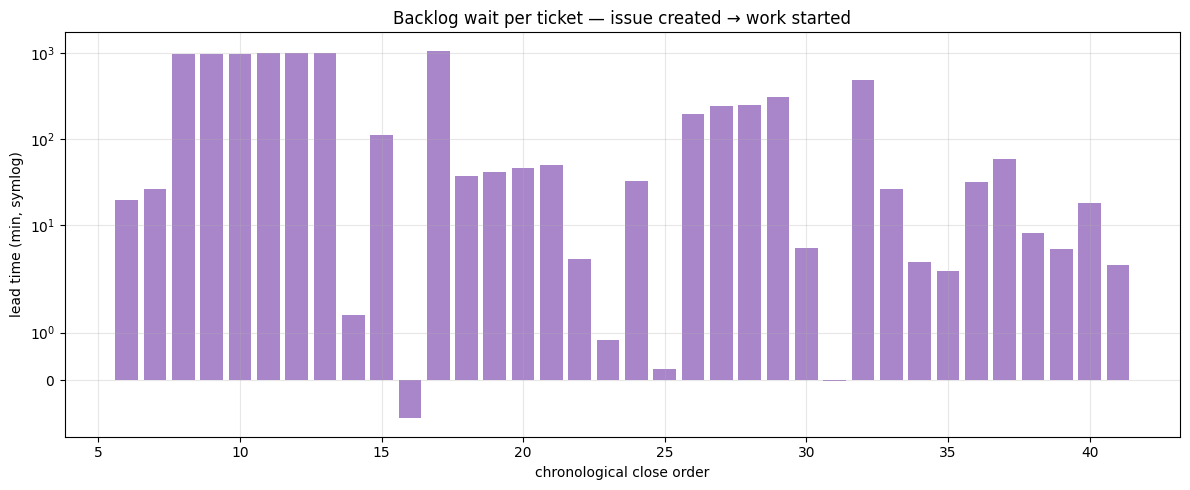

Median lead time: 34.9 min
Just-in-time (lead < 5 min): 9 / 36 tickets
Backlog (lead > 60 min):     13 / 36 tickets


In [8]:
lead = df.dropna(subset=["lead_min"]).copy() if df["lead_min"].notna().any() else df.copy()
lead = df[pd.to_numeric(df["lead_min"], errors="coerce").notna()].copy()
lead["lead_min"] = pd.to_numeric(lead["lead_min"])

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(lead["seq"], lead["lead_min"], color="#9467bd", alpha=0.8)
ax.set_yscale("symlog")
ax.set(xlabel="chronological close order", ylabel="lead time (min, symlog)",
       title="Backlog wait per ticket — issue created → work started")
plt.tight_layout(); plt.show()

print(f"Median lead time: {lead['lead_min'].median():.1f} min")
print(f"Just-in-time (lead < 5 min): {(lead['lead_min'] < 5).sum()} / {len(lead)} tickets")
print(f"Backlog (lead > 60 min):     {(lead['lead_min'] > 60).sum()} / {len(lead)} tickets")


## 7. Do the notes-flags explain the outliers?

Test the notes' own hypotheses: **test-loop** and **overrun** tasks should have *lower*
C-ratio (effort pulled up toward/past the estimate); **worktree** is process overhead.

In [9]:
flag_summary = []
for flag in ["f_worktree", "f_overrun", "f_test_loop", "f_retro_c"]:
    on = has_c[has_c[flag] == True]
    off = has_c[has_c[flag] != True]
    flag_summary.append({
        "flag": flag, "n_on": len(on),
        "c_ratio_on": round(on["c_ratio"].mean(), 2) if len(on) else None,
        "c_ratio_off": round(off["c_ratio"].mean(), 2) if len(off) else None,
    })
fs = pd.DataFrame(flag_summary)
display(fs)
print("Test-loop tasks should show c_ratio_on < c_ratio_off if the 'loop pulls actuals up'")
print("hypothesis holds — i.e. less over-padding (tighter to estimate) when a test loop runs.")


,flag,n_on,c_ratio_on,c_ratio_off
0,f_worktree,14,3.58,2.71
1,f_overrun,2,0.63,3.19
2,f_test_loop,2,1.27,3.15
3,f_retro_c,2,7.08,2.81


Test-loop tasks should show c_ratio_on < c_ratio_off if the 'loop pulls actuals up'
hypothesis holds — i.e. less over-padding (tighter to estimate) when a test loop runs.


## 8. Takeaways

- **Systematic over-padding.** The median calibrated estimate is ~2–3x the actual
  hands-on time. The forecasting bias is consistent across roles and persists even
  after explicit "calibrate down" corrections.
- **The two overruns are both test-loop DEV work** (#135, #141) — the edit→assemble→run→diff
  loop is the one shape that reliably eats budget, supporting the notes' hypothesis.
- **ARC/research spikes are the most over-padded** — padding for unknowns that don't
  materialize once context is warm (#146 at 11x is the extreme).
- **LOC is a weak effort proxy but a good drift flag.** Effort here is dominated by
  reading/verifying, not typing — so high-LOC/low-time rows are bulk generation and
  low-LOC/high-time rows are investigation.
- **Most tickets are just-in-time** (lead < 5 min) — PDD puzzles filed as work begins —
  with a few genuine backlog items.

### Enrichment ideas not yet wired (future work)
- **Per-pass churn for multi-commit tickets** (e.g. #162 spanned 4 worktree commits;
  only the final SHA's churn is captured). Could map all commits referencing `#N`.
- **`git log --follow` blame age** of touched lines → "how old is the code I'm changing"
  as a true drift/staleness metric.
- **Comment-vs-code ratio** of the diff (the project is doc-heavy; separating prose
  churn from logic churn would sharpen the LOC signal).
- **Compaction/idle detection** from `span_min` − `actual_min` to quantify session
  fragmentation.
